### Feature Analysis

####  *AUTHOR:* Ehsan Farahbakhsh
####  *CONTACT:* e.farahbakhsh@sydney.edu.au
####  *DATE last modified:* 05/08/2025

In [1]:
from ipywidgets import interact
import os

from gplately import EARTH_RADIUS
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pulearn import BaggingPuClassifier
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy import stats
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import IterativeImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real

from lib.feature_analysis import *
from lib.feature_extraction import *

from parameters import parameters

In [2]:
buffer_distance = parameters["buffer_distance"]
num_random = parameters["num_random"]
columns_to_drop_deposit = parameters["columns_to_drop_deposit"]
columns_to_drop_unlabelled = parameters["columns_to_drop_unlabelled"]

outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]

deposit_data_filename = parameters["deposit_data_filename"]
unlabelled_data_filename = parameters["unlabelled_data_filename"]
features_imputed_weight_label_filename = parameters["features_imputed_weight_label_filename"]
corr_filename = parameters["corr_filename"]
Xy_train_original_filename = parameters["Xy_train_original_filename"]
Xy_pos_test_original_filename = parameters["Xy_pos_test_original_filename"]
Xy_train_filename = parameters["Xy_train_filename"]
Xy_pos_test_filename = parameters["Xy_pos_test_filename"]
Xy_train_new_filename = parameters["Xy_train_new_filename"]

robust_scaler_filename = parameters["robust_scaler_filename"]
model_pub_filename = parameters["model_pub_filename"]

ml_dir = os.path.join(outputs_dir, ml_dir)
if not os.path.exists(ml_dir):
    os.makedirs(ml_dir, exist_ok=True)

deposit_data_filename = os.path.join(outputs_dir, deposit_data_filename)
unlabelled_data_filename = os.path.join(outputs_dir, unlabelled_data_filename)
features_imputed_weight_label_filename = os.path.join(outputs_dir, features_imputed_weight_label_filename)
corr_filename = os.path.join(outputs_dir, corr_filename)
Xy_train_original_filename = os.path.join(ml_dir, Xy_train_original_filename)
Xy_pos_test_original_filename = os.path.join(ml_dir, Xy_pos_test_original_filename)
Xy_train_filename = os.path.join(ml_dir, Xy_train_filename)
Xy_pos_test_filename = os.path.join(ml_dir, Xy_pos_test_filename)
Xy_train_new_filename = os.path.join(ml_dir, Xy_train_new_filename)

robust_scaler_filename = os.path.join(ml_dir, robust_scaler_filename)
model_pub_filename = os.path.join(ml_dir, model_pub_filename)

n_jobs = 20

In [3]:
if os.path.isfile(features_imputed_weight_label_filename):
    features_imputed_weight_label = pd.read_csv(features_imputed_weight_label_filename)
else:
    deposit_data = pd.read_csv(deposit_data_filename)
    print("Number of deposits:", len(deposit_data))
    distance_threshold = np.deg2rad(buffer_distance) * EARTH_RADIUS
    count = (deposit_data["distance_to_trench (km)"] > distance_threshold).sum()
    print("Out of", len(deposit_data), "deposits", count, "are located further than the", int(distance_threshold), "km distance threshold.")
    unlabelled_data = pd.read_csv(unlabelled_data_filename)

    deposit_data["label"] = 1
    unlabelled_data["label"] = 0

    deposit_labels = deposit_data["label"]
    unlabelled_labels = unlabelled_data["label"]
    
    deposit_weights = deposit_data["weight"]
    unlabelled_weights = unlabelled_data["weight"]
    
    n_target = num_random * len(deposit_data)
    unlabelled_data_sampled = downsample(unlabelled_data, n_target=n_target, random_state=42)
    print("Number of unlabelled samples:", len(unlabelled_data_sampled))

    deposit_features = deposit_data.drop(columns=columns_to_drop_deposit)
    unlabelled_features_sampled = unlabelled_data_sampled.drop(columns=columns_to_drop_unlabelled)
    features_sampled = pd.concat([deposit_features, unlabelled_features_sampled], ignore_index=True)
    labels = pd.concat([deposit_labels, unlabelled_labels], ignore_index=True)
    weights = pd.concat([deposit_weights, unlabelled_weights], ignore_index=True)
    
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(random_state=42),
        random_state=42,
    )
    features_imputed_array = imputer.fit_transform(features_sampled)

    features_imputed = pd.DataFrame(features_imputed_array, columns=features_sampled.columns)
    features_imputed_weight_label = features_imputed.copy()
    features_imputed_weight_label["weight"] = weights
    features_imputed_weight_label["label"] = labels
    features_imputed_weight_label.to_csv(features_imputed_weight_label_filename, index=False)

features_imputed = features_imputed_weight_label.drop(["weight", "label"], axis=1)

### Correlation

In [4]:
if os.path.isfile(corr_filename):
    corr = pd.read_csv(corr_filename, index_col=0)
else:
    corr = features_imputed.corr(method="spearman").round(3)
    corr.to_csv(corr_filename, index=True)
    
correlations = analyze_correlations(corr, threshold=0.8)
generate_report(correlations, threshold=0.8)

Correlation Analysis Report (Threshold: 0.8)

Feature: convergence_rate_orthogonal (cm/yr)
------------------------------
Positive Correlations:
  water_flux (m^2/yr): 0.961
  slab_flux (m^2/yr): 0.933
  convergence_rate (cm/yr): 0.919
  carbon_flux (t/m/yr): 0.851

Feature: crustal_pore_water_thickness (m)
------------------------------
Negative Correlations:
  plate_thickness (m): -1.000
  seafloor_age (Ma): -1.000
  crustal_bound_water_thickness (m): -0.980
  crustal_carbon_density (t/m^2): -0.936

Feature: trench_velocity (cm/yr)
------------------------------
Negative Correlations:
  trench_velocity_orthogonal (cm/yr): -0.921

Feature: water_flux (m^2/yr)
------------------------------
Positive Correlations:
  convergence_rate_orthogonal (cm/yr): 0.961
  slab_flux (m^2/yr): 0.959
  sediment_flux (m^2/yr): 0.878
  convergence_rate (cm/yr): 0.875
  carbon_flux (t/m/yr): 0.831

Feature: crustal_carbon_density (t/m^2)
------------------------------
Positive Correlations:
  plate_thick

### Dendrogram

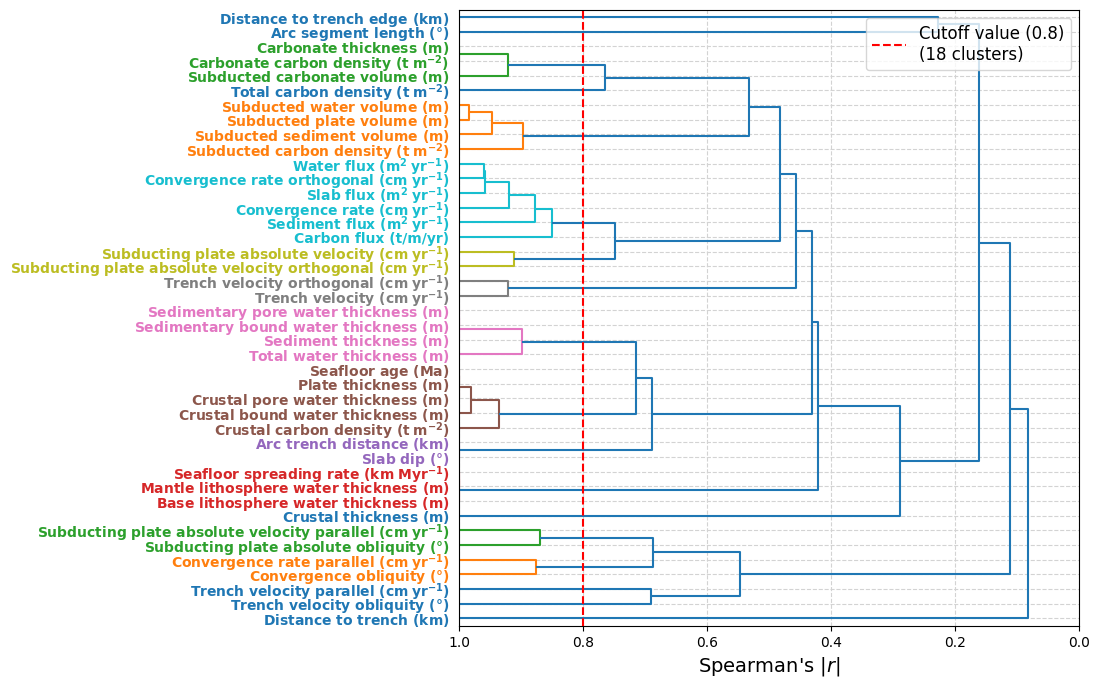

In [5]:
cutoff_value = 0.8
cluster_threshold = 1 - cutoff_value

Z = linkage(
    features_imputed.T,
    method="single",
    metric=lambda x, y: 1.0 - np.abs(spearmanr(x, y).statistic),
)

cluster_ids = fcluster(Z, cluster_threshold, criterion="distance")
clusters = {
    cluster_id: list(features_imputed.columns[cluster_ids == cluster_id])
    for cluster_id in np.unique(cluster_ids)
}

fig, ax = plt.subplots(figsize=(8, 8))
dendro = dendrogram(
    Z,
    orientation="right",
    labels=[format_feature_name(i, bold=True) for i in features_imputed.columns],
    ax=ax,
    color_threshold=cluster_threshold,
)
ax.axvline(
    cluster_threshold,
    linestyle="dashed",
    color="red",
    zorder=10,
    label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} clusters)",
)
ax.grid(linestyle="dashed", color="lightgrey")
ax.set_xticks(ax.get_xticks(), [f"{1 - i:0.1f}" for i in ax.get_xticks()])
ax.set_xlabel(r"Spearman's $|r|$", fontsize=14)
ax.tick_params(labelsize=10)
for i, j in zip(ax.get_ymajorticklabels(), dendro["leaves_color_list"]):
    i.set_color(j)
    i.set_fontweight("bold")
ax.legend(loc="best", fontsize=12)

In [6]:
for cluster_id in sorted(clusters.keys()):
    cluster_features = clusters[cluster_id]
    print(f"Cluster #{cluster_id}:")
    for feature in cluster_features:
        print(f"  - {feature}")

Cluster #1:
  - trench_velocity_obliquity (degrees)
Cluster #2:
  - trench_velocity_parallel (cm/yr)
Cluster #3:
  - convergence_obliquity (degrees)
  - convergence_rate_parallel (cm/yr)
Cluster #4:
  - subducting_plate_absolute_obliquity (degrees)
  - subducting_plate_absolute_velocity_parallel (cm/yr)
Cluster #5:
  - base_lithosphere_water_thickness (m)
  - mantle_lithosphere_water_thickness (m)
  - seafloor_spreading_rate (km/Myr)
Cluster #6:
  - slab_dip (degrees)
  - arc_trench_distance (km)
Cluster #7:
  - crustal_pore_water_thickness (m)
  - crustal_carbon_density (t/m^2)
  - crustal_bound_water_thickness (m)
  - plate_thickness (m)
  - seafloor_age (Ma)
Cluster #8:
  - sedimentary_bound_water_thickness (m)
  - sedimentary_pore_water_thickness (m)
  - total_water_thickness (m)
  - sediment_thickness (m)
Cluster #9:
  - trench_velocity (cm/yr)
  - trench_velocity_orthogonal (cm/yr)
Cluster #10:
  - subducting_plate_absolute_velocity_orthogonal (cm/yr)
  - subducting_plate_absolut

Text(0, 0.5, 'Number of remaining features')

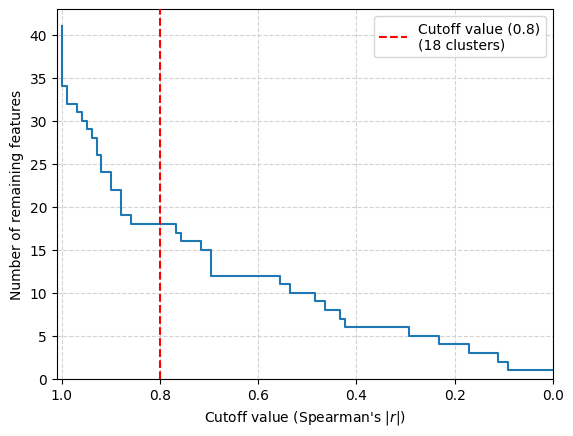

In [7]:
thresh_vals = np.linspace(0, 1, 100)
thresh_clusters = np.array([
    len(np.unique(fcluster(Z, 1 - t, criterion="distance")))
    for t in thresh_vals
])

fig, ax = plt.subplots()
ax.step(thresh_vals, thresh_clusters, where="post")
ax.axvline(
    cutoff_value,
    linestyle="dashed",
    color="red",
    zorder=10,
    label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} clusters)",
)
ax.set_xlim(thresh_vals.max() * 1.01, thresh_vals.min())
ax.set_ylim(0, None)
ax.grid(linestyle="dashed", color="lightgrey")
ax.legend(loc="best")
ax.set_xlabel(r"Cutoff value (Spearman's $|r|$)")
ax.set_ylabel("Number of remaining features")

### Selected Features

In [8]:
selected_features = [
#     "arc_segment_length (degrees)",
#     "arc_trench_distance (km)",
#     "base_lithosphere_water_thickness (m)",
#     "carbon_flux (t/m/yr)",
#     "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "convergence_obliquity (degrees)",
    "convergence_rate (cm/yr)",
#     "convergence_rate_orthogonal (cm/yr)",
#     "convergence_rate_parallel (cm/yr)",
#     "crustal_bound_water_thickness (m)",
#     "crustal_carbon_density (t/m^2)",
#     "crustal_pore_water_thickness (m)",
    "crustal_thickness (m)",
#     "distance_from_trench_start (km)",
    "distance_to_trench (km)",
    "distance_to_trench_edge (km)",
#     "mantle_lithosphere_water_thickness (m)",
#     "plate_thickness (m)",
    "seafloor_age (Ma)",
    "seafloor_spreading_rate (km/Myr)",
#     "sediment_flux (m^2/yr)",
    "sediment_thickness (m)",
#     "sedimentary_bound_water_thickness (m)",
#     "sedimentary_pore_water_thickness (m)",
    "slab_dip (degrees)",
#     "slab_flux (m^2/yr)",
#     "subducted_carbon_density (t/m^2)",
#     "subducted_carbonate_volume (m)",
#     "subducted_plate_volume (m)",
    "subducted_sediment_volume (m)",
#     "subducted_water_volume (m)",
    "subducting_plate_absolute_obliquity (degrees)",
    "subducting_plate_absolute_velocity (cm/yr)",
#     "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
#     "subducting_plate_absolute_velocity_parallel (cm/yr)",
    "total_carbon_density (t/m^2)",
#     "total_water_thickness (m)",
#     "trench_normal_angle (degrees)",
    "trench_velocity (cm/yr)",
    "trench_velocity_obliquity (degrees)",
#     "trench_velocity_orthogonal (cm/yr)",
    "trench_velocity_parallel (cm/yr)",
#     "water_flux (m^2/yr)",
]

### Train-Test Split

In [9]:
selected_features_weight = selected_features.copy()
selected_features_weight.append("weight")

if os.path.isfile(robust_scaler_filename):
    robust_scaler = joblib.load(robust_scaler_filename)
    Xy_train_original = pd.read_csv(Xy_train_original_filename)
    Xy_train = pd.read_csv(Xy_train_filename)
    Xy_pos_test = pd.read_csv(Xy_pos_test_filename)
else:
    deposit_features_imputed_weight_label = features_imputed_weight_label[features_imputed_weight_label["label"] == 1]
    unlabelled_features_imputed_weight_label = features_imputed_weight_label[features_imputed_weight_label["label"] == 0]

    deposit_features_imputed_weight = deposit_features_imputed_weight_label[selected_features_weight]
    unlabelled_features_imputed_weight = unlabelled_features_imputed_weight_label[selected_features_weight]

    deposit_labels = deposit_features_imputed_weight_label["label"]
    unlabelled_labels = unlabelled_features_imputed_weight_label["label"]

    # split positive samples into train and test datasets
    X_pos_train, X_pos_test, y_pos_train, y_pos_test = train_test_split(deposit_features_imputed_weight, deposit_labels, train_size=0.8, random_state=42)
    X_train = np.vstack((X_pos_train, unlabelled_features_imputed_weight))
    y_train = np.vstack((y_pos_train.values.reshape(-1, 1), unlabelled_labels.values.reshape(-1, 1)))

    selected_features_weight_label = selected_features_weight.copy()
    selected_features_weight_label.append("label")

    Xy_train_original = np.hstack((X_train, y_train))
    Xy_train_original = pd.DataFrame(Xy_train_original, columns=selected_features_weight_label)
    Xy_train_original.to_csv(Xy_train_original_filename, index=False)

    Xy_train_features = Xy_train_original[selected_features]
    Xy_train_labels = Xy_train_original["label"]
    Xy_train_weights = Xy_train_original["weight"]

    robust_scaler = RobustScaler()
    X_train = robust_scaler.fit_transform(Xy_train_features)
    Xy_train = np.hstack((X_train, Xy_train_weights.values.reshape(-1, 1), Xy_train_labels.values.reshape(-1, 1)))
    Xy_train = pd.DataFrame(Xy_train, columns=selected_features_weight_label)
    Xy_train.to_csv(Xy_train_filename, index=False)

    Xy_pos_test_original = np.hstack((X_pos_test, y_pos_test.values.reshape(-1, 1)))
    Xy_pos_test_original = pd.DataFrame(Xy_pos_test_original, columns=selected_features_weight_label)
    Xy_pos_test_original.to_csv(Xy_pos_test_original_filename, index=False)

    Xy_pos_test_features = Xy_pos_test_original[selected_features]
    Xy_pos_test_labels = Xy_pos_test_original["label"]
    Xy_pos_test_weights = Xy_pos_test_original["weight"]

    X_pos_test = robust_scaler.transform(Xy_pos_test_features)
    Xy_pos_test = np.hstack((X_pos_test, Xy_pos_test_weights.values.reshape(-1, 1), Xy_pos_test_labels.values.reshape(-1, 1)))
    Xy_pos_test = pd.DataFrame(Xy_pos_test, columns=selected_features_weight_label)
    Xy_pos_test.to_csv(Xy_pos_test_filename, index=False)

    joblib.dump(robust_scaler, robust_scaler_filename)
    
    print("Number of positive training samples:", X_pos_train.shape[0])
    print("Number of unlabelled training samples:", unlabelled_features_imputed_weight.shape[0])
    print("Number of positive testing samples:", X_pos_test.shape[0])

### Positive and Unlabelled Bagging

In [10]:
features_pub = Xy_train[[col for col in Xy_train.columns if col not in ["weight", "label"]]]
labels_pub = Xy_train["label"]
weights_pub = Xy_train["weight"]

if os.path.isfile(model_pub_filename):
    model_pub = joblib.load(model_pub_filename)
else:
    # Random Forest model structure
    rf_pub = RandomForestClassifier(n_jobs=n_jobs, random_state=42)
    pub = BaggingPuClassifier(rf_pub, n_jobs=n_jobs, random_state=42)

    n_fold = 10

    search_space = {
    "estimator__bootstrap": Categorical([True, False]),
    "estimator__max_depth": Integer(5, 20),
    "estimator__max_features": Categorical([None, "sqrt","log2"]), 
    "estimator__min_samples_leaf": Integer(2, 20),
    "estimator__min_samples_split": Integer(2, 30),
    "estimator__n_estimators": Integer(10, 200),
#     "base_estimator__bootstrap": Categorical([True, False]),
#     "base_estimator__max_depth": Integer(5, 20),
#     "base_estimator__max_features": Categorical([None, "sqrt","log2"]), 
#     "base_estimator__min_samples_leaf": Integer(2, 20),
#     "base_estimator__min_samples_split": Integer(2, 30),
#     "base_estimator__n_estimators": Integer(10, 200),
    "max_samples": Integer(int(0.5*(len(labels_pub)-sum(labels_pub))), int(0.9*(len(labels_pub)-sum(labels_pub))))
    }

    pub_bayes_search = BayesSearchCV(pub,
                                     search_space,
                                     n_iter=50, # specify how many iterations
                                     scoring="f1",
                                     n_jobs=n_jobs,
                                     cv=n_fold,
                                     verbose=1,
                                     random_state=42)
    pub_bayes_search.fit(features_pub, labels_pub, sample_weight=weights_pub)
    
    # Extract the optimization results
    optimization_results = pub_bayes_search.cv_results_["mean_test_score"]
    
    model_pub = pub_bayes_search.best_estimator_
    model_pub_f1 = pub_bayes_search.best_score_    
    print("The highest F1-score during cross validation:", model_pub_f1)
    
    # Save the model
    joblib.dump(model_pub, model_pub_filename)
    
    # Plot the Bayesian optimization progress
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(optimization_results) + 1), optimization_results, marker="o", color="black", markerfacecolor="red")
    plt.xlim(0, len(optimization_results) + 1)
    plt.xlabel("Bayesian Optimization Iteration")
    plt.ylabel("Mean Test F1 Score")
    plt.title("Bayesian Optimization Progress")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

In [11]:
X_pos_test = Xy_pos_test[[col for col in Xy_pos_test.columns if col not in ["weight", "label"]]]
y_pos_test = Xy_pos_test["label"]
weights_pos_test = Xy_pos_test["weight"]
X_pos_pred = model_pub.predict(X_pos_test)
X_pos_pred_acc = accuracy_score(y_pos_test, X_pos_pred, sample_weight=weights_pos_test)
print("Accuracy:", X_pos_pred_acc)

Accuracy: 0.815018315018315


In [12]:
if os.path.isfile(Xy_train_new_filename):
    Xy_train_new = pd.read_csv(Xy_train_new_filename)
else:
    labels_pred = model_pub.predict(features_pub)
    
    labels_new = []
    for real, pred in zip(labels_pub, labels_pred):
        if real == 1:
            labels_new.append(1)
        elif pred == 1:
            labels_new.append(2)
        else:
            labels_new.append(0)

    Xy_train_new = features_pub.copy()
    Xy_train_new["weight"] = weights_pub
    Xy_train_new["label"] = labels_new
    Xy_train_new.to_csv(Xy_train_new_filename, index=False)

### Histogram

In [13]:
Xy_train_new_filtered = Xy_train_new[Xy_train_new["label"] != 2]
Xy_train_new_filtered_labels = Xy_train_new_filtered["label"]
Xy_train_new_filtered = Xy_train_new_filtered.drop(["weight", "label"], axis=1)
Xy_train_new_filtered_original_values = Xy_train_new_filtered * robust_scaler.scale_ + robust_scaler.center_
Xy_train_new_filtered_original_values["label"] = Xy_train_new_filtered_labels

# Separate the data by label
negatives = Xy_train_new_filtered_original_values[Xy_train_new_filtered_original_values["label"] == 0]
positives = Xy_train_new_filtered_original_values[Xy_train_new_filtered_original_values["label"] == 1]

@interact
def show_hist(feature=selected_features):
    # Create the plot
    fig, ax = plt.subplots()
    ax.set_facecolor("whitesmoke")

    # Histogram for negatives
    counts_neg, bins, _ = ax.hist(negatives[feature], bins=30, facecolor="LightSalmon", edgecolor="black", 
            label="Negative", density=True, alpha=1)

    # Histogram for positives
    counts_pos, _, _ = ax.hist(positives[feature], bins=bins, facecolor="DarkSeaGreen", edgecolor="black", 
            label="Positive", density=True, alpha=0.6)

    # Labels and legend
    ax.set_xlabel(format_feature_name(feature))
    ax.set_ylabel("Probability Density")
    ax.legend(loc="best")

    fig.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('carbonate_thickness (m)', 'convergence_obliqui…

### Violin-Box Plot

In [14]:
labels = Xy_train_new_filtered_original_values["label"].unique()

@interact
def show_violin_box(feature=selected_features):
    plot_data = [Xy_train_new_filtered_original_values[Xy_train_new_filtered_original_values["label"] == label][feature] for label in labels]
    
    fig, ax = plt.subplots()
    ax.set_facecolor("whitesmoke")
    
    colors = ["DarkSeaGreen", "LightSalmon"]
    
    vplot_parts = ax.violinplot(plot_data, positions=np.arange(len(labels)))
    for i, body in enumerate(vplot_parts["bodies"]):
        body.set_facecolor(colors[i])
        body.set_edgecolor(colors[i])
    for partname in ("cbars", "cmins", "cmaxes"):
        vp = vplot_parts.get(partname)
        if vp:
            vp.set_edgecolor("black")
    
    bp = ax.boxplot(plot_data, positions=np.arange(len(labels)), patch_artist=True,
                    whis=(5, 95), widths=0.2,
                    flierprops=dict(marker=".", markersize=8, markerfacecolor="red", markeredgecolor="black"),
                    medianprops=dict(color="black", linewidth=1.5),
                    whiskerprops=dict(color="black", linestyle="-"),
                    capprops=dict(color="none"))  # "hide" caps
    
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    
    ax.set_xticklabels(["Positive", "Negative"])
    ax.set_ylabel(format_feature_name(feature))
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('carbonate_thickness (m)', 'convergence_obliqui…